##Machine Learning: Utilização de Autograd e Otimização de Parâmetros

Autor: Leandro Belo de Almeida Gomes

Objetivo:Em vez de definir manualmente os pesos ($w$) e o viés ($b$), utilizarei o motor de diferenciação automática do PyTorch (Autograd) para treinar o modelo.

O modelo partirá de valores aleatórios e, através de um loop de treinamento, ajustará seus parâmetros para minimizar o erro (Loss) em relação a um gabarito (Labels).

Lobo abaixo será reaproveitado a estrutura de tensores e o agnosticismo de hardware do Caso 2 "Refatoração: De NumPy para PyTorch (Tensores)", mas adicionando os Labels.

In [5]:
import torch
import torch.optim as optim

# Configuração de Hardware
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Dados de entrada (Coordenadas x, y)
pontos = torch.tensor([[1.0, 2.0], [3.0, 4.0], [5.0, 1.0]], device=device)

# O "Gabarito" (Labels): O que o modelo deve aprender a classificar
# 1.0 para classe A, 0.0 para classe B (exemplo)
labels = torch.tensor([[0.0], [1.0], [0.0]], device=device)

print(f"Dados prontos no dispositivo: {device}")

Dados prontos no dispositivo: cuda


In [9]:
# Inicialização aleatória
weights = torch.randn(2, 1, requires_grad=True, device=device)
bias = torch.randn(1, requires_grad=True, device=device)

## Configuração do Otimizador (Stochastic Gradient Descent)
## teste de erros e acertos
learning_rate = 0.001 ## quanto menor o rate mais preciso para quantidade menores
                      ## de dados
optimizer = optim.SGD([weights, bias], lr=learning_rate)

# Critério de Erro (Loss Function)
criterion = torch.nn.MSELoss()

In [25]:
epochs = 500  # Quantidade de iterações de aprendizado

print("Iniciando treinamento...")
for epoch in range(epochs):
    # 1. Forward: Previsão baseada nos pesos atuais
    outputs = torch.matmul(pontos, weights) + bias

    # 2. Cálculo do Erro: Mostra a previsão com o gabarito
    loss = criterion(outputs, labels)

    # 3. Backward: O Autograd calcula a influência de cada peso no erro
    optimizer.zero_grad() # Limpa gradientes de rodadas anteriores
    loss.backward()       # Backpropagation

    # 4. Step: Otimizador ajusta os pesos (weights e bias)
    optimizer.step()

    if (epoch + 1) % 50 == 0:
        print(f"Época [{epoch+1}/{epochs}], Erro (Loss): {loss.item():.4f}")

print("\nTreinamento concluído!")

Iniciando treinamento...
Época [50/500], Erro (Loss): 0.0041
Época [100/500], Erro (Loss): 0.0041
Época [150/500], Erro (Loss): 0.0040
Época [200/500], Erro (Loss): 0.0039
Época [250/500], Erro (Loss): 0.0039
Época [300/500], Erro (Loss): 0.0038
Época [350/500], Erro (Loss): 0.0037
Época [400/500], Erro (Loss): 0.0037
Época [450/500], Erro (Loss): 0.0036
Época [500/500], Erro (Loss): 0.0036

Treinamento concluído!


In [26]:
print(f"Pesos Finais (Aprendidos): \n{weights.detach().cpu().numpy()}")
print(f"Bias Final (Aprendido): {bias.detach().item():.4f}")

# Teste simples de inferência
with torch.no_grad():
    teste = torch.matmul(pontos, weights) + bias
    print(f"\nPrevisões finais do modelo:\n{teste}")

Pesos Finais (Aprendidos): 
[[0.12981948]
 [0.440088  ]]
Bias Final (Aprendido): -1.0998

Previsões finais do modelo:
tensor([[-0.0898],
        [ 1.0500],
        [-0.0106]], device='cuda:0')


In [27]:
historico_loss = [] # Lista para armazenar o erro de cada época

for epoch in range(epochs):
    outputs = torch.matmul(pontos, weights) + bias
    loss = criterion(outputs, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # .item() extrai o valor numérico do tensor
    historico_loss.append(loss.item())

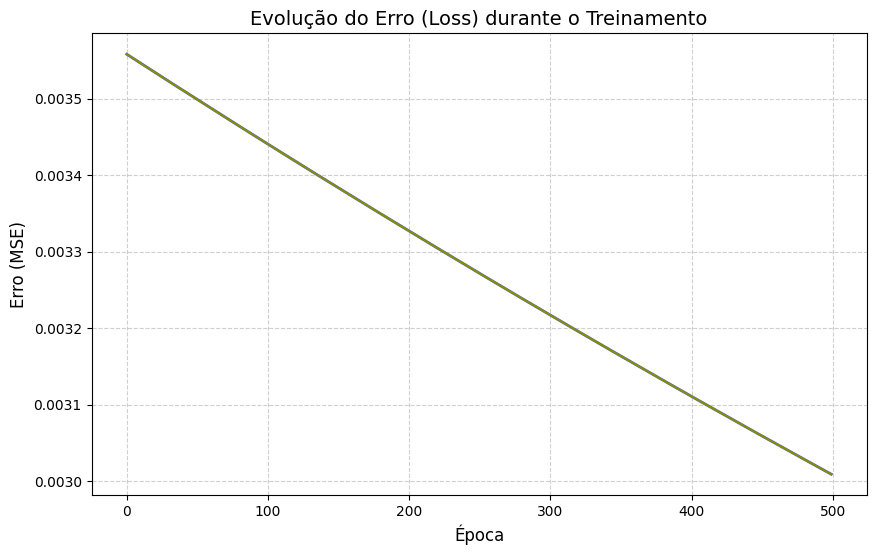

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(historico_loss, color='royalblue', linewidth=2)
plt.title('Evolução do Erro (Loss) durante o Treinamento', fontsize=14)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Erro (MSE)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.plot(historico_loss, color='#8B8B00')
plt.show()